# RippleNet_interactive_prototype
Test implementation of user-interactive detection and rejection of detected SPW-R events using RippleNet.

Author: Espen Hagen (<https://github.com/espenhgn>)

LICENSE: <https://github.com/CINPLA/RippleNet/blob/master/LICENSE>

In [1]:
# allow running on Google Colab for training, validation etc. 
try:
    from google.colab import drive
    drive.mount('/content/gdrive')
    %cd gdrive/My\ Drive/Colab\ Notebooks/RippleNet
    %tensorflow_version 2.x
except:
    pass

In [2]:
%matplotlib widget

Matplotlib is building the font cache; this may take a moment.


In [3]:
import os
import numpy as np
import scipy.signal as ss
import matplotlib.pyplot as plt
from matplotlib.widgets import Button
import tensorflow
import tensorflow as tf
from tensorflow import keras
import h5py
from matplotlib import colors
from time import time, sleep
import pickle
import pandas as pd
from datetime import datetime

In [4]:
from tensorflow.python.client import device_lib
print('running Tensorflow v{}'.format(tf.__version__))
print('running on devices:\n', device_lib.list_local_devices())
print('Num GPUs Available: ', len(tf.config.experimental.list_physical_devices('GPU')))
print('GPU device:\n', tf.test.gpu_device_name())

running Tensorflow v2.13.0
running on devices:
 [name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 12573422229336157541
xla_global_id: -1
]
Num GPUs Available:  0
GPU device:
 


In [5]:
# fix seeds for reproducible results
np.random.seed(1234)
tf.random.set_seed(12345)

# Load RippleNet instance

In [6]:
# load info on best model (path, threhsold settings)
with open('best_model.pkl', 'rb') as f:
    best_model = pickle.load(f)
    print(best_model)

{'model_file': 'trained_networks/ripplenet_bidirectional_random_seed123.h5', 'threshold': 0.7, 'width': 0.0, 'distance': 62}


In [7]:
# load the 'best' performing model on the validation sets
model = keras.models.load_model(best_model['model_file'])
model.summary()

Model: "RippleNet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, 1)]         0         
                                                                 
 gaussian_noise (GaussianNo  (None, None, 1)           0         
 ise)                                                            
                                                                 
 conv1d (Conv1D)             (None, None, 20)          220       
                                                                 
 batch_normalization (Batch  (None, None, 20)          80        
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, None, 20)          0         
                                                                 
 conv1d_1 (Conv1D)           (None, None, 10)          22

# Parameters

In [8]:
# some needed parameters
Fs = 1250 # Hz, sampling freq
lag = int(100 * Fs / 1000) # 100 ms @ Fs

# Threshold settings for detecting ripple events from prediction, 
threshold = best_model['threshold'] # detection threshold on the interval (0, 1)
distance = best_model['distance']  # timesteps, distance*Fs/1000 peak interdistance in units of ms
width = best_model['width']       # timesteps, width*Fs/1000 peak width in units of ms. 
# see scipy.signal.find_peaks documentation

In [9]:
# bandpass-filter LFP filter settings
Wn = (150 / (Fs / 2), 250 / (Fs / 2)) # critical frequencies
N = 2                                 # filter order
b, a = ss.butter(N, Wn, btype='bandpass') # filter coefficients 

In [10]:
# Wavelet parameters for spectrograms
S_freqs = np.arange(100., 251, 10) # Hz, wavelet spectrogram frequencies

#set up continuous wavelets
w=6.
s=1.

#wavelets
waveletfun = ss.morlet
wavelets = []
for i, freq in enumerate(S_freqs):
    kwargs = {
        'M' : int(2. * s * Fs * w / freq),
        'w' : w,
        's' : s,
        'complete' : True,
    }
    wl = waveletfun(**kwargs)
    wavelets.append(wl)

# Session time series

Load `HDF5` file with raw LFP trace for processing. The file must be structured as follows:
```
/<session_name>          Group                # group for session data
/<session_name>/lfp      Dataset {753914}     # input LFP in units of mV [mandatory], float type
/<session_name>/S        Dataset {753914, 16} # spectrogram [optional], float type
/<session_name>/S_freqs  Dataset {16}         # spectrogram center frequencies [optional], float type
/<session_name>/X1       Dataset {753914}     # signal (e.g., band-pass filtered LFP) [optional], float type
/<session_name>/rippleLocs Dataset {86}       # ripple locations in units of time steps [optional], int type
/<session_name>/run_speed Dataset {753914}    # run speed [optional], int/float type
/<session_name>/y        Dataset {753914}     # one-hot encoding of ripple events [optional], float type
```

## open file with complete LFP time series:
Adapt `session` and `file_path` below accordingly. 

If `file_mode` equals `r+` RippleNet predictions (ripple locations) and  data segments  (lfp, lfp_bp, spectrograms) will be  stored in the file, if `file_mode` equals `r`, the input file will be left untouched. 

In [11]:
file_mode = 'r' 
session = 'm4029_session1'  # holdout dataset
file_path = os.path.join('data', '{}.h5'.format(session))
f = h5py.File(file_path, file_mode)
print('opened file {} ({})'.format(file_path, f))

opened file data\m4029_session1.h5 (<HDF5 file "m4029_session1.h5" (mode r)>)


# Run RippleNet on data
Two operation modes are possible.  
If `continuous_prediction==True` (not recommended for now) use entire time series as input,  
if `continuous_prediction==False` (recommended) reshape input LFP into segments of lengths `Fs` (i.e., 1s) and use as input. 

This operation may take a moment.

In [16]:
# Switch or reshaping into 1s segments, running 
continuous_prediction = False

# input must have correct shape (n_samples, n_timesteps, 1)
lfp = f[session]['lfp'][:]
print(lfp.shape)
# Switch or reshaping input into segments, or running on full time series
if continuous_prediction:
    # Predict using entire dataset at once
    Y_cont_pred = model.predict(np.expand_dims(np.expand_dims(lfp, 0), -1))
else:
    # Reshape time axis to segments of Fs duration
    segment_length = int(0.5 * Fs) # Fs = 0.5s segments

    # run predictions n times with shifts of length segment_length / n,
    # then final output will be averaged
    n = 5 # nicely divisible with Fs=1250
    shift = int(segment_length / n)
    container = []
    for i in range(n):
        lfp_reshaped = np.concatenate((np.zeros((1, i * shift, 1)), 
                                       np.expand_dims(np.expand_dims(lfp, 0), -1)), axis=1)
        print ('shifted input shape:', lfp_reshaped.shape)
        # pad with zeros 
        lfp_reshaped = np.concatenate((lfp_reshaped, 
                                         np.zeros((1, segment_length - 
                                                   (lfp_reshaped.size % segment_length), 1))), 
                                        axis=1)
        
        # reshape into segments of length  
        lfp_reshaped = lfp_reshaped.reshape((-1, segment_length, 1))
        print('reshaped input shape:', lfp_reshaped.shape)
        # run prediction on data
        y_hat = model.predict(lfp_reshaped)
        print('raw output shape:', y_hat.shape)
        # Reshape to zero-padded size
        y_hat = y_hat.reshape((1, -1, 1))[:, :lfp_reshaped.size, :]
        print('reshaped output shape:', y_hat.shape)
        # strip elements that were padded with zeros
        container.append(y_hat[:, i * shift:i * shift + lfp.size, :])

    # average or median
    y_hat = np.median(container, axis=0).flatten()

    # remove intermediate predictions
    del container, lfp_reshaped

(753914,)
shifted input shape: (1, 753914, 1)
reshaped input shape: (1207, 625, 1)
38/38 [==============================] - 4s 72ms/step
raw output shape: (1207, 625, 1)
reshaped output shape: (1, 754375, 1)
shifted input shape: (1, 754039, 1)
reshaped input shape: (1207, 625, 1)
38/38 [==============================] - 3s 74ms/step
raw output shape: (1207, 625, 1)
reshaped output shape: (1, 754375, 1)
shifted input shape: (1, 754164, 1)
reshaped input shape: (1207, 625, 1)
38/38 [==============================] - 3s 68ms/step
raw output shape: (1207, 625, 1)
reshaped output shape: (1, 754375, 1)
shifted input shape: (1, 754289, 1)
reshaped input shape: (1207, 625, 1)
38/38 [==============================] - 3s 71ms/step
raw output shape: (1207, 625, 1)
reshaped output shape: (1, 754375, 1)
shifted input shape: (1, 754414, 1)
reshaped input shape: (1208, 625, 1)
38/38 [==============================] - 3s 70ms/step
raw output shape: (1208, 625, 1)
reshaped output shape: (1, 755000, 1)


In [38]:
y_hat = y_hat.flatten()
print(np.max(y_hat))

0.99956685


## Find peaks in the prediction `y_hat`

In [18]:
ripple_locations, _ = ss.find_peaks(y_hat, height=threshold, distance=distance, width=width)

In [19]:
# remove ripple locations in movement periods (within 0.5s of movement event)
if 'run_speed' in list(f[session].keys()):
    # smoothen run_speed by 1s boxcar filter:
    run_speed = np.convolve(f[session]['run_speed'], ss.boxcar(Fs) / Fs, 'same')
    # keep ripples where run_speed == 0:
    ripple_locations = ripple_locations[run_speed[ripple_locations] == 0]

In [20]:
# define `probability` as value of y_hat at time of events
# (so not in the strict sense as in statistics)
probability = y_hat[ripple_locations]

## Get samples of LFPs etc. for each detected ripple event

In [21]:
def get_samples(lfp, lfp_bp, lfp_S, ripple_locations, lag=100, Fs=1250):
    '''
    Parameters:
    -----------
    Returns:
    --------
    '''
    # create arrays
    X = [] # container for raw data segments
    X_bp = [] # container for gamma-band data segments
    X_S = []  # container for specgram
    
    sample_size = lag * 2 + 1

    for ind in ripple_locations:
        offset = -sample_size // 2        
        
        idx = np.arange(sample_size) + ind + offset
        if idx.min() < 0:
            idx -= idx.min()
        elif idx.max() >= lfp.size:
            idx = idx - (idx.max() - lfp.size + 1) 
        X.append(lfp[idx])
        X_bp.append(lfp_bp[idx])
        X_S.append(lfp_S[idx, ])
        
    # convert to numpy arrays, downcast to single precision
    X = np.array(X).astype(np.float32)
    X_bp = np.array(X_bp).astype(np.float32)
    X_S = np.array(X_S).astype(np.float32)
    
    return X, X_bp, X_S

In [22]:
# fetch or compute bandpass-filtered LFP
if 'X1' in list(f[session].keys()):
    lfp_bp = f[session]['X1'][:]
else:
    lfp_bp = ss.filtfilt(b, a, f[session]['lfp'][:])

In [23]:
# Container for spectrograms
lfp_S = np.empty((lfp.size, S_freqs.size), dtype=complex)

#apply wavelets
for i, wavelet in enumerate(wavelets):
    lfp_S[:, i] = ss.convolve(lfp.flatten(), wavelet, 'same')

# compute envelope
lfp_S = np.abs(lfp_S).astype(np.float32)**2

## Get samples around ripple locations

In [24]:
# X: LFPs
# X_bp: band-pass filtered LFPs
# X_S: spectrograms
X, X_bp, X_S = get_samples(lfp, lfp_bp, lfp_S, ripple_locations, lag=lag, Fs=Fs)

In [25]:
# time vector relative to event
lags = (np.arange(lag * 2 + 1) - lag) * 1000 / Fs

In [26]:
# min and max in colormap range (as exp(pc) lower 1% and upper 99% percentiles pc of log(X_S))
vmin, vmax = np.exp(np.percentile(np.log(X_S.flatten()), [1, 99]))

In [27]:
# define log-linear colormap norm
norm = colors.LogNorm(vmin=vmin, vmax=vmax)
# or linear colormap norm
# norm = colors.Normalize(vmin=vmin, vmax=vmax)

## plot samples, reject noise events etc.

Define sorting order (either `chronological`, `probability`, `probability_reversed`, `random`, `None`)

In [28]:
sort_order = 'random'

if sort_order is None or sort_order == 'chronological':
    sorting = np.arange(X.shape[0])
elif sort_order == 'random':
    sorting = np.random.permutation(np.arange(X.shape[0]))
elif sort_order == 'probability':
    sorting = np.argsort(probability)[::-1]
elif sort_order == 'probability_reversed':
    sorting = np.argsort(probability)

In [29]:
def remove_axis_junk(ax, lines=['right', 'top', 'bottom']):
    """remove chosen lines from plotting axis"""
    for loc, spine in ax.spines.items():
        if loc in lines:
            spine.set_color('none')
    #ax.xaxis.set_ticks_position('bottom')
    ax.xaxis.set_ticks_position('none')  
    #ax.yaxis.set_ticks_position('left')

### Define class for plot

In [30]:
class RippleNetPlot:
    '''Main object for figure, axes and mouse-click events'''
    def __init__(self, ncols=5, 
                 figsize=(9,5), 
                 cmap='inferno',
                 norm=colors.LogNorm(vmin=vmin, vmax=vmax)):
        '''
        Parameters
        ----------
        ncols: int
            number of columns per view
        figsize: tuple floats
            length 2 tuple (width, height) in inches.
        cmap: str or mpl.colors.cmap
            colormap (default: 'inferno')
        norm: mpl.colors.Normalize instance
            default: mpl.colors.LogNorm(vmin=1pc, vmax=99pc)
        '''
        # create figure and axes
        nrows = 3
        
        (self.fig, self.axes) = plt.subplots(nrows, ncols, sharex=True, sharey='row', figsize=figsize)
        self.fig.subplots_adjust(left=0.1, right=0.95, bottom=0.1, top=0.92, wspace=0.05)
        
        # annotate plots
        self.axes[0, 0].set_ylabel('(mV)', labelpad=0)
        self.axes[1, 0].set_ylabel('(mV)', labelpad=0)
        self.axes[2, 0].set_ylabel('$f$ (Hz)', labelpad=0)
        self.axes[2, 0].set_xticks([lags[0], 0, lags[-1]])
        self.axes[2, 0].set_xticklabels([lags[0], 0, None])
        self.axes[2, 0].set_xlabel(r'$\tau$ (ms)', labelpad=0)
        
        self.axes[0, 0].set_ylim(-0.5, 0.5)
        self.axes[1, 0].set_ylim(-0.1, 0.1)
        
        for ax in self.axes[:2, :].flatten():
            remove_axis_junk(ax)

        self.nrows = nrows
        self.ncols = ncols

        self.cmap = cmap
        
        self._event_axes = []

        self.rejected = []

        self.button_presses = 0

        self.cid = self.fig.canvas.mpl_connect('button_press_event', self.on_click)


    def on_click(self, event):
        '''
        Detects mouse click in axes
        '''
        if event.inaxes == axnext:
            self._event_axes = []
            return # ignore clicks on button

        if event.inaxes in self.axes[2, :]: # ignore clicks on spectrograms
            return
        
        (_, col) = np.where(self.axes == event.inaxes)
        
        if not event.inaxes in self._event_axes:
            for ax in self.axes[:, col]:
                self._event_axes.append(ax)

            self.rejected.append(col[0] + self.button_presses * self.ncols)

            event.inaxes.patch.set_facecolor('gray')
        else:
            for ax in self.axes[:, col]:
                self._event_axes.remove(ax)

            self.rejected.remove(col[0] + self.button_presses * self.ncols)

            event.inaxes.patch.set_facecolor('white')

        plt.gcf().canvas.draw()

        return

### Create interactive plot:
Feel free to chance `ncols`, `figsize` and `cmap` (https://matplotlib.org/tutorials/colors/colormaps.html) below.  
Don't click *both* LFP and band-pass LFP in a single column. Weird things may happen. 

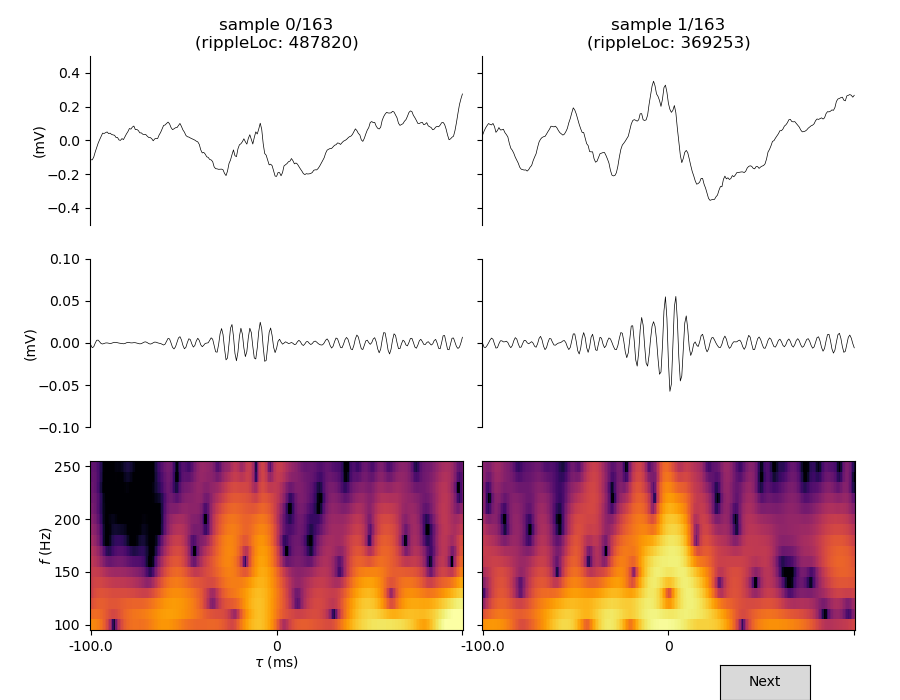

In [31]:
plt.close('all')
# create interactive plot
plot = RippleNetPlot(ncols=2, 
                     figsize=(9,7), 
                     cmap='inferno', 
                     norm=norm)
axes = plot.axes

for j in range(plot.ncols):
    try:
        k = sorting[j]
        plot.axes[0, j].plot(lags, X[k] - X[k].mean(), 'k', lw=0.5, clip_on=False)
        plot.axes[0, j].set_title('sample {}/{}\n(rippleLoc: {})'.format(
            j, ripple_locations.size, ripple_locations[sorting][j]))
        plot.axes[1, j].plot(lags, X_bp[k], 'k', lw=0.5, clip_on=False)
        plot.axes[2, j].pcolormesh(lags, S_freqs, X_S[k].T,
                                   norm=colors.LogNorm(vmin=vmin, vmax=vmax),
                                   cmap=plot.cmap,
                                   shading='auto')
    except IndexError:
        plot.axes[0, j].axis('off')
        plot.axes[1, j].axis('off')
        plot.axes[2, j].axis('off')

class ButtonPresses(object):
    button_presses = 0

    def next(self, event):
        self.button_presses += 1

        plot.button_presses = self.button_presses

        for j in range(plot.ncols):
            try:
                k = sorting[self.button_presses * plot.ncols + j]
                plot.axes[0, j].lines[0].set_ydata(X[k] - X[k].mean())
                plot.axes[0, j].set_title('sample {}/{}\n(rippleLoc: {})'.format(
                    self.button_presses * plot.ncols + j,
                    ripple_locations.size, 
                    ripple_locations[sorting][self.button_presses * plot.ncols + j]))
                plot.axes[1, j].lines[0].set_ydata(X_bp[k])
                plot.axes[0, j].axis(plot.axes[0, j].axis('tight'))
                plot.axes[2, j].collections[0].set_array(X_S[k].T)
            except IndexError:
                plot.axes[0, j].lines.pop()
                plot.axes[1, j].lines.pop()
                plot.axes[2, j].collections.pop()
                plot.axes[0, j].axis('off')
                plot.axes[1, j].axis('off')
                plot.axes[2, j].axis('off')

        
        for ax in plot.axes.flatten():
            ax.patch.set_facecolor('white')
        plt.gcf().canvas.draw()

        return

callback = ButtonPresses()
axnext = plt.axes([0.8, 0.0, 0.1, 0.05])
bnext = Button(axnext, 'Next')
bnext.on_clicked(callback.next)
plt.show()

## Process output
Dump label times and status to `.csv`

In [32]:
raise Exception # ugly, break execution

Exception: 

In [33]:
# create array of rejected (noise) events
rejected = np.array(plot.rejected, dtype=int) 
rejected = rejected[rejected < ripple_locations.size]

# crate boolean label array for every ripple location (True - ripple event, False - noise event)
ripple_labels = np.ones(ripple_locations.size, dtype=bool)
ripple_labels[sorting[rejected]] = False

# create dataframe for writing
df = pd.DataFrame(data=dict(rippleLocs=ripple_locations[sorting], 
                            ripple=ripple_labels[sorting]))
df

,rippleLocs,ripple
0,487820,True
1,369253,True
2,372680,True
3,531005,True
4,691862,True
...,...,...
158,692517,True
159,583609,True
160,434102,True
161,396210,True


In [34]:
# count numbers of true and false ripples
df.groupby('ripple').count()

,rippleLocs
ripple,
True,163


In [35]:
# save dataframe to .csv file
fname = '{}_ripples_{}.csv'.format(session, datetime.now().strftime("%Y.%m.%d_%H:%M"))
with open(fname, 'w') as f:
    df.to_csv(f, index=False)
    print('data written to {}'.format(fname))

data written to m4029_session1_ripples_2025.12.29_10:58.csv
